Industry Gaps & Comparisons - Adewale 

Which industries show the largest gap between industry expectations and what educational institutions are preparing? Use the matching dataset and postings to find mismatches.

What role does programming language preference play depending on job role or industry?
Analyze frequency/preference of languages across job categories.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
from wordcloud import WordCloud

In [8]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [51]:
#df1 = pd.read_csv(r'C:\Users\tosth\OneDrive\Documents\TKH-Capstone-Project\TKH-Capstone-Project\datasets\job_skills.csv')
df = pd.read_csv(r'C:\Users\tosth\OneDrive\Documents\TKH-Capstone-Project\TKH-Capstone-Project\datasets\job_postings.csv') 

In [52]:
print("="*50)
print("BASIC DATASET INFORMATION")
print("="*50)

# View first few rows
print("\nFirst 5 rows of data:")
print(df.head())


# Column names
print("\nColumn Names:")
print(df.columns.tolist())

# Data types
print("\nData Types:")
print(df.dtypes)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Basic statistics
print("\nBasic Statistics:")
print(df.describe)

BASIC DATASET INFORMATION

First 5 rows of data:
                                            job_link  \
0  https://www.linkedin.com/jobs/view/senior-mach...   
1  https://www.linkedin.com/jobs/view/principal-s...   
2  https://www.linkedin.com/jobs/view/senior-etl-...   
3  https://www.linkedin.com/jobs/view/senior-data...   
4  https://www.linkedin.com/jobs/view/lead-data-e...   

             last_processed_time   last_status got_summary got_ner  \
0  2024-01-21 08:08:48.031964+00  Finished NER           t       t   
1  2024-01-20 04:02:12.331406+00  Finished NER           t       t   
2  2024-01-21 08:08:31.941595+00  Finished NER           t       t   
3  2024-01-20 15:30:55.796572+00  Finished NER           t       t   
4  2024-01-21 08:08:58.312124+00  Finished NER           t       t   

  is_being_worked                                     job_title  \
0               f              Senior Machine Learning Engineer   
1               f  Principal Software Engineer, ML Accelera

In [58]:

# Remove duplicates
original_rows = len(df1)
df = df.drop_duplicates()
print(f"Removed {original_rows - len(df)} duplicate rows")


Removed 0 duplicate rows


In [43]:
print("\n" + "="*50)
print("TOP SKILLS ANALYSIS")
print("="*50)

# This function extracts skills from job descriptions or skills columns
def extract_common_skills(text_series):
    """
    Extract common data science skills from text
    """
    # Common data science skills to look for
    skills_keywords = [
        'python', 'r', 'sql', 'java', 'scala', 'julia',
        'machine learning', 'deep learning', 'neural network',
        'tensorflow', 'pytorch', 'keras', 'scikit-learn',
        'pandas', 'numpy', 'matplotlib', 'seaborn',
        'tableau', 'power bi', 'excel',
        'aws', 'azure', 'gcp', 'cloud',
        'hadoop', 'spark', 'kafka',
        'docker', 'kubernetes', 'git',
        'nlp', 'computer vision', 'statistics',
        'a/b testing', 'experimentation',
        'communication', 'business acumen'
    ]
    
    skills_count = Counter()
    
    for text in text_series.dropna():
        text_lower = str(text).lower()
        for skill in skills_keywords:
            if skill in text_lower:
                skills_count[skill] += 1
    
    return skills_count


TOP SKILLS ANALYSIS


In [59]:
# Apply to your skills or description column
# MODIFY 'job_description' to match your actual column name
if 'job_skill' in df.columns:
    skills_counter = extract_common_skills(df['job_link'])
elif 'skills' in df.columns:
    skills_counter = extract_common_skills(df['job_skills'])
else:
    print("Warning: No description or skills column found. Update the column name!")
    skills_counter = Counter()

# Get top 20 skills
top_skills = dict(skills_counter.most_common(20))
print("\nTop 20 Most Requested Skills:")
for skill, count in top_skills.items():
    print(f"{skill.title()}: {count}")


Top 20 Most Requested Skills:


In [60]:
# First, check what columns you actually have
print("Available columns in your dataset:")
print(df.columns.tolist())

# Look for a column with job descriptions or skills
# Common names: 'description', 'job_description', 'skills', 'requirements', 'job_details'

Available columns in your dataset:
['job_link', 'last_processed_time', 'last_status', 'got_summary', 'got_ner', 'is_being_worked', 'job_title', 'company', 'job_location', 'first_seen', 'search_city', 'search_country', 'search_position', 'job_level', 'job_type']



✓ Saved: top_skills_industry.png


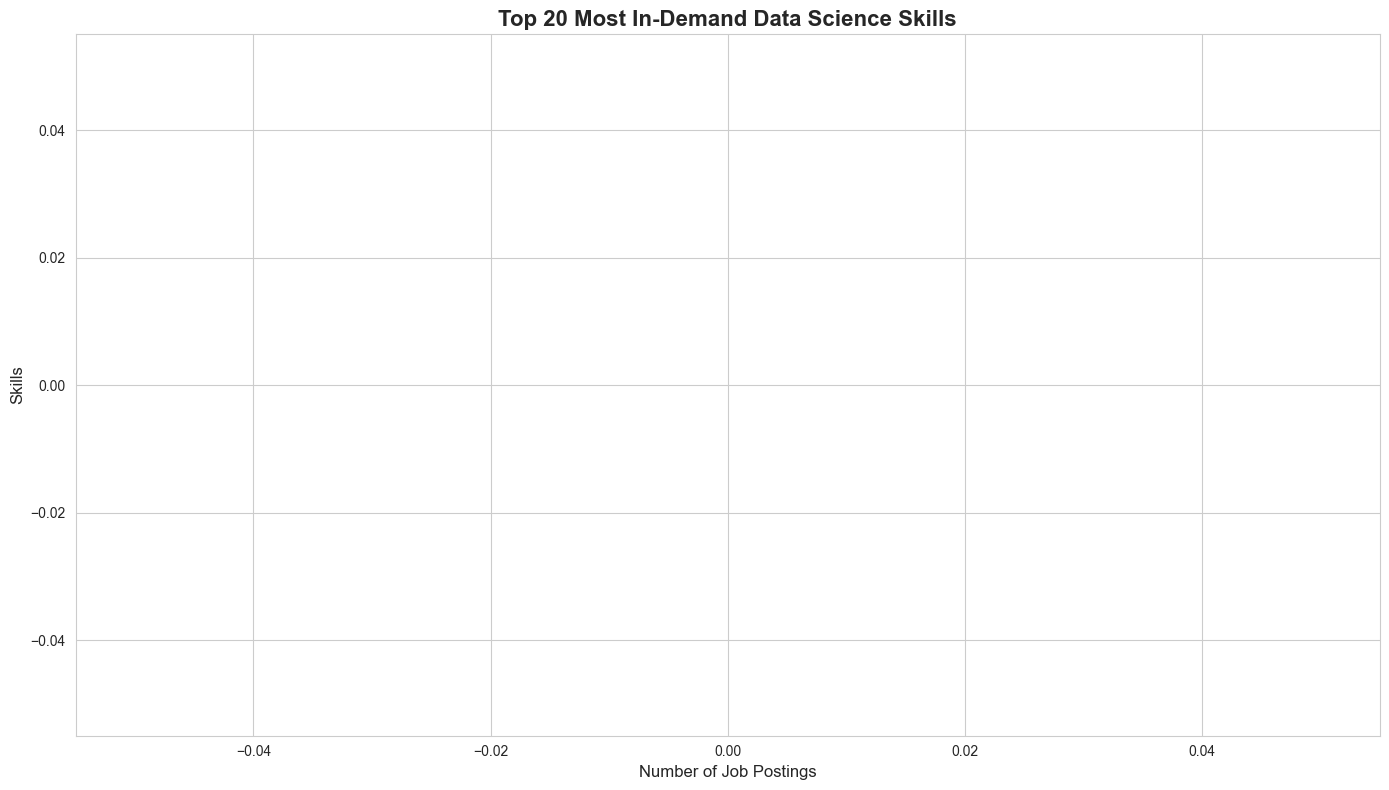

In [62]:
plt.figure(figsize=(14, 8))
skills_df = pd.DataFrame(list(top_skills.items()), 
                         columns=['Skill', 'Frequency'])
skills_df = skills_df.sort_values('Frequency', ascending=True)

plt.barh(skills_df['Skill'], skills_df['Frequency'], color='steelblue')
plt.xlabel('Number of Job Postings', fontsize=12)
plt.ylabel('Skills', fontsize=12)
plt.title('Top 20 Most In-Demand Data Science Skills', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('top_skills_industry.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: top_skills_industry.png")
plt.show()

In [24]:
# Check if there are any NaN values
print("Technical count:", technical_count)
print("Soft count:", soft_count)

# Create the DataFrame
skills_type = pd.DataFrame({
    'Skill Type': ['Technical Skills', 'Soft Skills'],
    'Mentions': [technical_count, soft_count]
})

# Remove NaN values and ensure counts are valid numbers
skills_type = skills_type.dropna()

# Only create pie chart if we have valid data
if len(skills_type) > 0 and skills_type['Mentions'].sum() > 0:
    colors = ['#2E86AB', '#A23B72']
    plt.figure(figsize=(8, 8))
    plt.pie(skills_type['Mentions'], labels=skills_type['Skill Type'], 
            autopct='%1.1f%%', colors=colors, startangle=90)
    plt.title('Technical vs Soft Skills in Job Requirements', 
              fontsize=16, fontweight='bold')
    plt.savefig('technical_vs_soft_skills.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No valid data to plot")

Technical count: 0
Soft count: 0
No valid data to plot
